In [1]:
import pandas as pd

# 2. Loading data
fire_04_23 = pd.read_csv("../data/fire_04_23.csv", sep = ",") #../ ist nötig, damit man aus dem notbook ordner kommmt und dann in den datd ordner

print("Data loaded successfully")

Data loaded successfully


In [2]:
# 3. Creating classes
import jenkspy

data = fire_04_23['size_ha']

# Calculate Natural Breaks (Jenks)
breaks = jenkspy.jenks_breaks(data, n_classes=5)

# Creating labels for the 5 classes
labels = [
    "Very small",
    "Small",
    "Medium",
    "Large",
    "Exremely large"
]

# Create classes
classes = pd.cut(fire_04_23['size_ha'], bins=breaks, include_lowest=True) 
# pd.cut nimmt die Werte von fire und ordnet sie Klassen zu
# inlcude_lowest = TRUE bewirkt dass der erste Wert auch in der ersten Klasse is (sonst wäre er nicht enthalten und es würde ein NaN geben)

# Count number of fires per class
table = classes.value_counts().sort_index()
# value_counts zählt wie viele Werte in jeder Klasse sind
# sort_index sortiert nach der Reihenfolge

# Convert to DataFrame
table = table.reset_index()


# Add ad column for the size names using the labels
table['size'] = labels

# Order and print table
table.columns = ['class intervals (ha)', 'number of fires', 'size']
table = table[['size', 'class intervals (ha)', 'number of fires']] # reorder the table so that size is first

table

,size,class intervals (ha),number of fires
0,Very small,"(199.999, 16842.0]",6702
1,Small,"(16842.0, 65433.969]",582
2,Medium,"(65433.969, 166856.9]",118
3,Large,"(166856.9, 363544.0]",34
4,Exremely large,"(363544.0, 885388.214]",13


In [16]:
# Adding the labels to the copy csv of fire_04_23
fire_tot = fire_04_23.copy()

fire_tot['size'] = pd.cut(
    fire_tot['size_ha'],
    bins = breaks,
    labels = labels,
    include_lowest = True
)

print(fire_04_23['size'].value_counts().sort_index())


display(fire_tot.head(5))

size
Very small        6702
Small              582
Medium             118
Large               34
Exremely large      13
Name: count, dtype: int64


,province,fire_id,latitude,longitude,year,size_ha,cause,size
0,Alberta,HWF175,57.552983,-115.553983,2023,251.80000,Unknown,Very small
1,Saskatchewan,23SR-LLHIR03,58.182064,-103.050880,2023,214.70000,Natural,Very small
2,Quebec,20231080689,50.571300,-79.304600,2023,19248.49051,Natural,Small
3,Saskatchewan,23LA-HARDY,55.622898,-106.395540,2023,314.00000,Natural,Very small
4,Saskatchewan,23BN-LINVALL,56.361978,-109.013426,2023,660.00000,Natural,Very small


In [17]:
# Exporting the fire data with the new size column as new csv in the folder data
fire_tot.to_csv("../data/fire_tot.csv", index = False)
print("Export successful")

Export successful


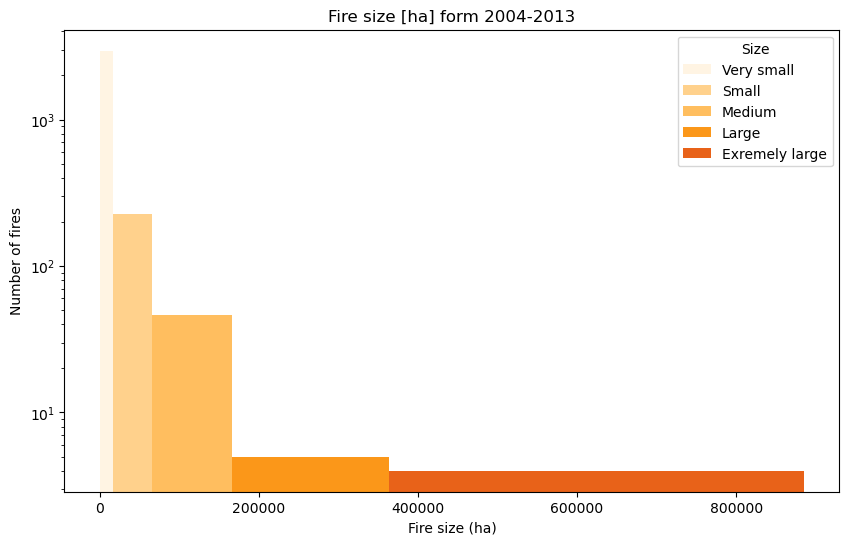

In [18]:
# 3. Histogram for 2004 - 2013
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# Years 2004-2013
histo_04_13 = fire_tot[
    (fire_tot['year'] >= 2004) &
    (fire_tot['year'] <= 2013)
]

Graph1 = histo_04_13['size_ha']

# Colors for each class
colors = [
    "#fff3e0",
    "#ffcc80",
    "#ffb74d",
    "#fb8c00",
    "#e65100"
]

# Create figure
plt.figure(figsize=(10,6))

# Plot each class separately
for i in range(len(breaks)-1):

    class_data = Graph1[
        (Graph1 >= breaks[i]) &
        (Graph1 <= breaks[i+1])
    ]

    plt.hist(
        class_data,
        bins=[breaks[i], breaks[i+1]],
        color=colors[i],
        alpha=0.9,
        label=labels[i]
    )

# logarithmische y-Achse
plt.yscale('log')

# Labels
plt.xlabel('Fire size (ha)')
plt.ylabel('Number of fires')
plt.title('Fire size [ha] form 2004-2013')
plt.legend(title = 'Size')

# Show plot
plt.show()

In [19]:
# 4. Table for 2004 - 2013

table_04_13 = (histo_04_13['size'].value_counts().reset_index())

table_04_13.columns = ['size', 'number of fires']

table_04_13

,size,number of fires
0,Very small,2951
1,Small,228
2,Medium,46
3,Large,5
4,Exremely large,4


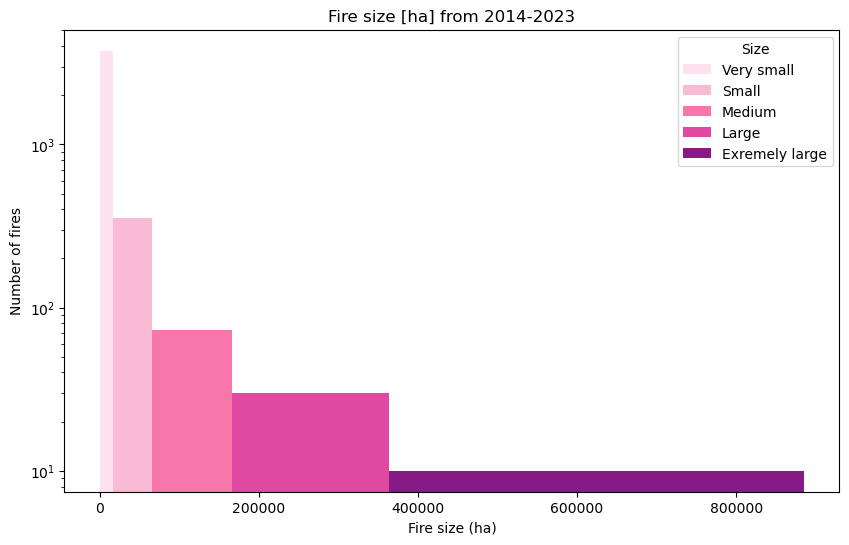

In [20]:
# 5. Histogram for 2014 - 2023
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import jenkspy

# Years 2004-2013
histo_14_23 = fire_tot[
    (fire_tot['year'] >= 2014) &
    (fire_tot['year'] <= 2023)
]

Graph2 = histo_14_23['size_ha']

# Colors for each class
colors = [
    "#fde0ef",
    "#f9b3d1",
    "#f768a1",
    "#dd3497",
    "#7a0177"
]

# Create figure
plt.figure(figsize=(10,6))

# Plot each class separately
for i in range(len(breaks)-1):

    class_data = Graph2[
        (Graph2 >= breaks[i]) &
        (Graph2 <= breaks[i+1])
    ]

    plt.hist(
        class_data,
        bins=[breaks[i], breaks[i+1]],
        color=colors[i],
        alpha=0.9,
        label=labels[i]
    )

# logarithmische y-Achse
plt.yscale('log')

# Labels
plt.xlabel('Fire size (ha)')
plt.ylabel('Number of fires')
plt.title('Fire size [ha] from 2014-2023')
plt.legend(title = 'Size')

# Show plot
plt.show()

In [21]:
# 6. Table for 2014 - 2023

table_14_23 = (histo_14_23['size'].value_counts().reset_index())

table_14_23.columns = ['size', 'number of fires']

table_14_23

,size,number of fires
0,Very small,3751
1,Small,354
2,Medium,72
3,Large,29
4,Exremely large,9
